In [1]:
# 5. Влияние алкоголя
plt.figure(figsize=(8, 5))
sns.barplot(x='alcohol_consumption', y='Label', data=df)
plt.title('Доля больных среди употребляющих и не употребляющих алкоголь', fontsize=14)
plt.xticks([0, 1], ['Не употребляют', 'Употребляют'])
plt.xlabel('Алкоголь', fontsize=12)
plt.ylabel('Доля больных', fontsize=12)
plt.show()

# 6. Влияние инфекции H. pylori
plt.figure(figsize=(8, 5))
sns.barplot(x='helicobacter_pylori_infection', y='Label', data=df)
plt.title('Доля больных среди инфицированных H. pylori', fontsize=14)
plt.xticks([0, 1], ['Не инфицированы', 'Инфицированы'])
plt.xlabel('H. pylori', fontsize=12)
plt.ylabel('Доля больных', fontsize=12)
plt.show()

# 7. Корреляционная матрица (только числовые)
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица', fontsize=14)
plt.show()

NameError: name 'plt' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# Загрузка данных
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')

print("="*60)
print("1. ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*60)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nТипы данных:")
print(df.dtypes.value_counts())

print("\n" + "="*60)
print("2. ПРОВЕРКА НА ПРОПУСКИ")
print("="*60)
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "Пропусков нет!")

print("\n" + "="*60)
print("3. ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("4. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (Label)")
print("="*60)
print(df['Label'].value_counts())
print("\nВ процентах:")
print(df['Label'].value_counts(normalize=True) * 100)

print("\n" + "="*60)
print("5. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*60)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head())

print("\n" + "="*60)
print("6. СРЕДНИЙ ВОЗРАСТ ПО СТАТУСУ")
print("="*60)
print(df.groupby('Label')['age'].agg(['mean', 'min', 'max']))

print("\n" + "="*60)
print("7. ВЛИЯНИЕ ФАКТОРОВ РИСКА")
print("="*60)
risk_factors = ['smoking_habits', 'alcohol_consumption', 'helicobacter_pylori_infection']
for factor in risk_factors:
    if factor in df.columns:
        risk = df.groupby(factor)['Label'].mean()
        print(f"\n{factor}:")
        print(f"  Доля больных: {risk[1]:.3f}" if 1 in risk.index else "")
        print(f"  Доля здоровых: {risk[0]:.3f}" if 0 in risk.index else "")

1. ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ
Размер датасета: 212354 строк, 29 столбцов

Типы данных:
str        11
float64    10
int64       8
Name: count, dtype: int64

2. ПРОВЕРКА НА ПРОПУСКИ
existing_conditions    42486
dtype: int64

3. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
                 age  family_history  smoking_habits  alcohol_consumption  \
count  212354.000000   212354.000000   212354.000000        212354.000000   
mean       53.258036        0.300564        0.399154             0.499378   
std        18.984419        0.458504        0.489726             0.500001   
min        20.000000        0.000000        0.000000             0.000000   
25%        37.000000        0.000000        0.000000             0.000000   
50%        50.000000        0.000000        0.000000             0.000000   
75%        69.000000        1.000000        1.000000             1.000000   
max        89.000000        1.000000        1.000000             1.000000   

       helicobacter_pylori_infection  target_entrez  targ

KeyError: 'Label'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# Загрузка данных
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')

print("="*60)
print("1. ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*60)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nТипы данных:")
print(df.dtypes.value_counts())

print("\n" + "="*60)
print("2. ПРОВЕРКА НА ПРОПУСКИ")
print("="*60)
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "Пропусков нет!")

print("\n" + "="*60)
print("3. ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*60)
print(df.describe())

# Автоматическое определение целевой переменной
possible_targets = ['Label', 'label', 'target', 'Target', 'diagnosis', 'class']
target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

# Если не найдена, берем последний столбец
if target_col is None:
    target_col = df.columns[-1]
    print(f"\n⚠️ Целевая переменная не найдена. Использую последний столбец: '{target_col}'")
else:
    print(f"\n✅ Целевая переменная: '{target_col}'")

print("\n" + "="*60)
print(f"4. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ({target_col})")
print("="*60)
print(df[target_col].value_counts())
print("\nВ процентах:")
print(df[target_col].value_counts(normalize=True) * 100)

print("\n" + "="*60)
print("5. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*60)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head())

print("\n" + "="*60)
print("6. СРЕДНИЙ ВОЗРАСТ ПО СТАТУСУ")
print("="*60)
print(df.groupby(target_col)['age'].agg(['mean', 'min', 'max']))

print("\n" + "="*60)
print("7. ВЛИЯНИЕ ФАКТОРОВ РИСКА")
print("="*60)
risk_factors = ['smoking_habits', 'alcohol_consumption', 'helicobacter_pylori_infection']
for factor in risk_factors:
    if factor in df.columns:
        risk = df.groupby(factor)[target_col].mean()
        print(f"\n{factor}:")
        if 1 in risk.index:
            print(f"  Доля больных: {risk[1]:.3f}")
        if 0 in risk.index:
            print(f"  Доля здоровых: {risk[0]:.3f}")

1. ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ
Размер датасета: 212354 строк, 29 столбцов

Типы данных:
str        11
float64    10
int64       8
Name: count, dtype: int64

2. ПРОВЕРКА НА ПРОПУСКИ
existing_conditions    42486
dtype: int64

3. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
                 age  family_history  smoking_habits  alcohol_consumption  \
count  212354.000000   212354.000000   212354.000000        212354.000000   
mean       53.258036        0.300564        0.399154             0.499378   
std        18.984419        0.458504        0.489726             0.500001   
min        20.000000        0.000000        0.000000             0.000000   
25%        37.000000        0.000000        0.000000             0.000000   
50%        50.000000        0.000000        0.000000             0.000000   
75%        69.000000        1.000000        1.000000             1.000000   
max        89.000000        1.000000        1.000000             1.000000   

       helicobacter_pylori_infection  target_entrez  targ

C:\Users\appol\AppData\Local\Temp\ipykernel_71768\3377847066.py:57: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


existing_conditions
Chronic Gastritis    106309
Diabetes              63559
Name: count, dtype: int64

endoscopic_images:
endoscopic_images
Normal      148523
Abnormal     63831
Name: count, dtype: int64

biopsy_results:
biopsy_results
Negative    191223
Positive     21131
Name: count, dtype: int64

ct_scan:
ct_scan
Negative    169740
Positive     42614
Name: count, dtype: int64

mature_mirna_acc:
mature_mirna_acc
MIR123    148596
MIR234     42474
MIR345     21284
Name: count, dtype: int64

mature_mirna_id:
mature_mirna_id
MIR123_1    148248
MIR234_2     42780
MIR345_3     21326
Name: count, dtype: int64

target_symbol:
target_symbol
TP53    106351
CDH1     63570
KRAS     42433
Name: count, dtype: int64

6. СРЕДНИЙ ВОЗРАСТ ПО СТАТУСУ
            mean  min  max
label                     
0      53.270916   20   89
1      53.140417   20   89

7. ВЛИЯНИЕ ФАКТОРОВ РИСКА

smoking_habits:
  Доля больных: 0.100
  Доля здоровых: 0.098

alcohol_consumption:
  Доля больных: 0.098
  Доля здоровых

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# Загрузка данных
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')

print("="*60)
print("1. ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*60)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nТипы данных:")
print(df.dtypes.value_counts())

print("\n" + "="*60)
print("2. ПРОВЕРКА НА ПРОПУСКИ")
print("="*60)
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "Пропусков нет!")

print("\n" + "="*60)
print("3. ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*60)
print(df.describe())

# Автоматическое определение целевой переменной
possible_targets = ['Label', 'label', 'target', 'Target', 'diagnosis', 'class']
target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

# Если не найдена, берем последний столбец
if target_col is None:
    target_col = df.columns[-1]
    print(f"\n⚠️ Целевая переменная не найдена. Использую последний столбец: '{target_col}'")
else:
    print(f"\n✅ Целевая переменная: '{target_col}'")

print("\n" + "="*60)
print(f"4. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ({target_col})")
print("="*60)
print(df[target_col].value_counts())
print("\nВ процентах:")
print(df[target_col].value_counts(normalize=True) * 100)

print("\n" + "="*60)
print("5. АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*60)
# Используем include=['object', 'category'] для корректной работы
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head())

print("\n" + "="*60)
print("6. СРЕДНИЙ ВОЗРАСТ ПО СТАТУСУ")
print("="*60)
print(df.groupby(target_col)['age'].agg(['mean', 'min', 'max']))

print("\n" + "="*60)
print("7. ВЛИЯНИЕ ФАКТОРОВ РИСКА")
print("="*60)
risk_factors = ['smoking_habits', 'alcohol_consumption', 'helicobacter_pylori_infection']
for factor in risk_factors:
    if factor in df.columns:
        risk = df.groupby(factor)[target_col].mean()
        print(f"\n{factor}:")
        if 1 in risk.index:
            print(f"  Доля больных: {risk[1]:.3f}")
        if 0 in risk.index:
            print(f"  Доля здоровых: {risk[0]:.3f}")

1. ОБЩАЯ ИНФОРМАЦИЯ О ДАННЫХ
Размер датасета: 212354 строк, 29 столбцов

Типы данных:
str        11
float64    10
int64       8
Name: count, dtype: int64

2. ПРОВЕРКА НА ПРОПУСКИ
existing_conditions    42486
dtype: int64

3. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
                 age  family_history  smoking_habits  alcohol_consumption  \
count  212354.000000   212354.000000   212354.000000        212354.000000   
mean       53.258036        0.300564        0.399154             0.499378   
std        18.984419        0.458504        0.489726             0.500001   
min        20.000000        0.000000        0.000000             0.000000   
25%        37.000000        0.000000        0.000000             0.000000   
50%        50.000000        0.000000        0.000000             0.000000   
75%        69.000000        1.000000        1.000000             1.000000   
max        89.000000        1.000000        1.000000             1.000000   

       helicobacter_pylori_infection  target_entrez  targ

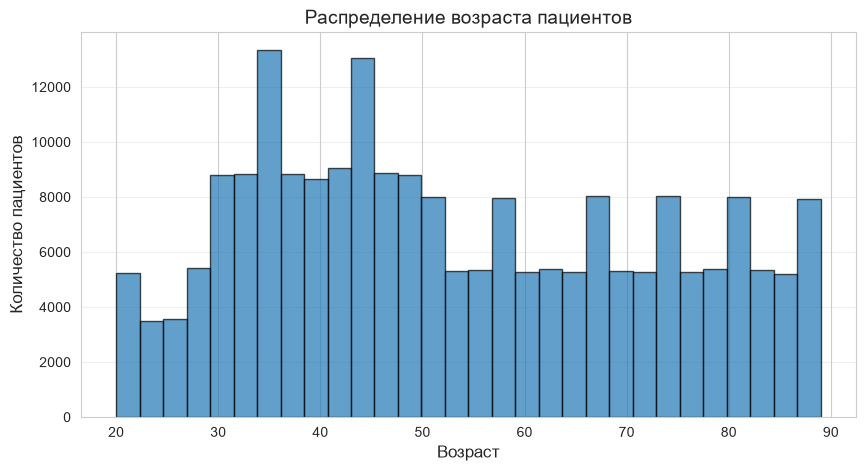

ValueError: Could not interpret value `Label` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

In [5]:
# 1. Гистограмма возраста
plt.figure(figsize=(10, 5))
plt.hist(df['age'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Распределение возраста пациентов', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Количество пациентов', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Распределение возраста по статусу (ящик с усами)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Label', y='age', data=df)
plt.title('Распределение возраста по статусу заболевания', fontsize=14)
plt.xticks([0, 1], ['Здоровые', 'Больные'])
plt.xlabel('Статус', fontsize=12)
plt.ylabel('Возраст', fontsize=12)
plt.show()

# 3. Соотношение больных и здоровых (круговая диаграмма)
plt.figure(figsize=(6, 6))
df['Label'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, 
                                     colors=['#66b3ff', '#ff6666'])
plt.title('Соотношение больных и здоровых', fontsize=14)
plt.ylabel('')
plt.show()

# 4. Столбчатая диаграмма: влияние курения
plt.figure(figsize=(8, 5))
sns.barplot(x='smoking_habits', y='Label', data=df)
plt.title('Доля больных среди курящих и некурящих', fontsize=14)
plt.xticks([0, 1], ['Не курят', 'Курят'])
plt.xlabel('Курение', fontsize=12)
plt.ylabel('Доля больных', fontsize=12)
plt.ylim(0, 0.2)
plt.show()

# 5. Влияние алкоголя
plt.figure(figsize=(8, 5))
sns.barplot(x='alcohol_consumption', y='Label', data=df)
plt.title('Доля больных среди употребляющих и не употребляющих алкоголь', fontsize=14)
plt.xticks([0, 1], ['Не употребляют', 'Употребляют'])
plt.xlabel('Алкоголь', fontsize=12)
plt.ylabel('Доля больных', fontsize=12)
plt.ylim(0, 0.2)
plt.show()

# 6. Влияние инфекции H. pylori
plt.figure(figsize=(8, 5))
sns.barplot(x='helicobacter_pylori_infection', y='Label', data=df)
plt.title('Доля больных среди инфицированных H. pylori', fontsize=14)
plt.xticks([0, 1], ['Не инфицированы', 'Инфицированы'])
plt.xlabel('H. pylori', fontsize=12)
plt.ylabel('Доля больных', fontsize=12)
plt.ylim(0, 0.2)
plt.show()

# 7. Корреляционная матрица (только числовые)
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5)
plt.title('Корреляционная матрица', fontsize=14)
plt.show()

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. EXTRACT (Извлечение данных)
# ==========================================
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')
print(f'Исходный размер: {df.shape}')

# ==========================================
# 2. TRANSFORM (Преобразование данных)
# ==========================================
# 2.1 Разделение признаков и целевой переменной
X = df.drop('Label', axis=1)  # Все столбцы, кроме Label — это признаки (Features)
y = df['Label']               # Label — это целевая переменная (Target)

# 2.2 Кодирование категориальных признаков
#     Нужно превратить текст (например, 'Male', 'Ethnicity_A') в числа для модели.
#     LabelEncoder кодирует каждую уникальную строку в число (0, 1, 2, ...).
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # Сохраняем, чтобы потом можно было "раскодировать"

print('Категориальные признаки закодированы.')

# 2.3 Разделение на обучающую, валидационную и тестовую выборки
#     Train: 70% - на этом наборе модель учится.
#     Validation: 15% - на этом наборе настраиваем гиперпараметры.
#     Test: 15% - на этом наборе проверяем финальную модель.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Размер Train: {X_train.shape[0]}')
print(f'Размер Validation: {X_val.shape[0]}')
print(f'Размер Test: {X_test.shape[0]}')

# ==========================================
# 3. LOAD (Загрузка обработанных данных)
# ==========================================
# 3.1 Объединяем обработанные признаки и целевую переменную обратно
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# 3.2 Сохраняем в папку processed в формате CSV
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/validation.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print('Готово! Данные сохранены в папку data/processed/')

ModuleNotFoundError: No module named 'sklearn'

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. EXTRACT (Извлечение данных)
# ==========================================
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')
print(f'Исходный размер: {df.shape}')

# ==========================================
# 2. TRANSFORM (Преобразование данных)
# ==========================================
# 2.1 Разделение признаков и целевой переменной
X = df.drop('Label', axis=1)  # Все столбцы, кроме Label — это признаки (Features)
y = df['Label']               # Label — это целевая переменная (Target)

# 2.2 Кодирование категориальных признаков
#     Нужно превратить текст (например, 'Male', 'Ethnicity_A') в числа для модели.
#     LabelEncoder кодирует каждую уникальную строку в число (0, 1, 2, ...).
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # Сохраняем, чтобы потом можно было "раскодировать"

print('Категориальные признаки закодированы.')

# 2.3 Разделение на обучающую, валидационную и тестовую выборки
#     Train: 70% - на этом наборе модель учится.
#     Validation: 15% - на этом наборе настраиваем гиперпараметры.
#     Test: 15% - на этом наборе проверяем финальную модель.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Размер Train: {X_train.shape[0]}')
print(f'Размер Validation: {X_val.shape[0]}')
print(f'Размер Test: {X_test.shape[0]}')

# ==========================================
# 3. LOAD (Загрузка обработанных данных)
# ==========================================
# 3.1 Объединяем обработанные признаки и целевую переменную обратно
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# 3.2 Сохраняем в папку processed в формате CSV
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/validation.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print('Готово! Данные сохранены в папку data/processed/')

ModuleNotFoundError: No module named 'sklearn'

In [8]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 3.1 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/8.2 MB 3.1 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/8.2 MB 3.1 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.2 MB 1.8 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.2 MB 2.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 2.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 2.7 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.2 MB 1.8 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.2 MB 1.8 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.2 MB 1.8 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.2 MB 1.8 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.2 MB 1.8 MB/s eta 0:00:03
   ----------------

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. EXTRACT (Извлечение данных)
# ==========================================
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')
print(f'Исходный размер: {df.shape}')

# ==========================================
# 2. TRANSFORM (Преобразование данных)
# ==========================================

# 2.1 Разделение признаков и целевой переменной
X = df.drop('Label', axis=1)  # Все столбцы, кроме Label — признаки
y = df['Label']               # Label — целевая переменная

# 2.2 Кодирование категориальных признаков
#     Превращаем текст (например, 'Male', 'Ethnicity_A') в числа
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # Сохраняем, чтобы потом можно было "раскодировать"

print('Категориальные признаки закодированы.')

# 2.3 Разделение на обучающую, валидационную и тестовую выборки
#     Train: 70% — модель учится
#     Validation: 15% — настройка гиперпараметров
#     Test: 15% — финальная проверка
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Размер Train: {X_train.shape[0]}')
print(f'Размер Validation: {X_val.shape[0]}')
print(f'Размер Test: {X_test.shape[0]}')

# ==========================================
# 3. LOAD (Загрузка обработанных данных)
# ==========================================

# 3.1 Объединяем обработанные признаки и целевую переменную обратно
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# 3.2 Сохраняем в папку processed в формате CSV
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/validation.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print('Готово! Данные сохранены в папку data/processed/')

Исходный размер: (212354, 29)


KeyError: "['Label'] not found in axis"

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. EXTRACT (Извлечение данных)
# ==========================================
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')
print(f'Исходный размер: {df.shape}')

# ==========================================
# 2. TRANSFORM (Преобразование данных)
# ==========================================

# 2.1 Разделение признаков и целевой переменной
X = df.drop('Label', axis=1)  # Все столбцы, кроме Label — признаки
y = df['Label']               # Label — целевая переменная

# 2.2 Кодирование категориальных признаков
#     Превращаем текст (например, 'Male', 'Ethnicity_A') в числа
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # Сохраняем, чтобы потом можно было "раскодировать"

print('Категориальные признаки закодированы.')

# 2.3 Разделение на обучающую, валидационную и тестовую выборки
#     Train: 70% — модель учится
#     Validation: 15% — настройка гиперпараметров
#     Test: 15% — финальная проверка
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Размер Train: {X_train.shape[0]}')
print(f'Размер Validation: {X_val.shape[0]}')
print(f'Размер Test: {X_test.shape[0]}')

# ==========================================
# 3. LOAD (Загрузка обработанных данных)
# ==========================================

# 3.1 Объединяем обработанные признаки и целевую переменную обратно
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# 3.2 Сохраняем в папку processed в формате CSV
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/validation.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print('Готово! Данные сохранены в папку data/processed/')

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. EXTRACT (Извлечение данных)
# ==========================================
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')
print(f'Исходный размер: {df.shape}')

# ==========================================
# 2. TRANSFORM (Преобразование данных)
# ==========================================

# 2.1 Разделение признаков и целевой переменной
X = df.drop('Label', axis=1)
y = df['Label']

# 2.2 Кодирование категориальных признаков
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print('Категориальные признаки закодированы.')

# 2.3 Разделение на выборки (ТОЛЬКО ЭТУ ЧАСТЬ ВЫ НЕДОКОПИРОВАЛИ)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Размер Train: {X_train.shape[0]}')
print(f'Размер Validation: {X_val.shape[0]}')
print(f'Размер Test: {X_test.shape[0]}')

# ==========================================
# 3. LOAD (Загрузка обработанных данных)
# ==========================================

# 3.1 Объединяем обработанные признаки и целевую переменную обратно
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# 3.2 Сохраняем в папку processed в формате CSV
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/validation.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print('Готово! Данные сохранены в папку data/processed/')

Исходный размер: (212354, 29)


KeyError: "['Label'] not found in axis"

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. EXTRACT (Извлечение данных)
# ==========================================
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')
print(f'Исходный размер: {df.shape}')

# ==========================================
# 2. TRANSFORM (Преобразование данных)
# ==========================================

# 2.1 Разделение признаков и целевой переменной
X = df.drop('Label', axis=1)
y = df['Label']

# 2.2 Кодирование категориальных признаков
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print('Категориальные признаки закодированы.')

# 2.3 Разделение на выборки (ТОЛЬКО ЭТУ ЧАСТЬ ВЫ НЕДОКОПИРОВАЛИ)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Размер Train: {X_train.shape[0]}')
print(f'Размер Validation: {X_val.shape[0]}')
print(f'Размер Test: {X_test.shape[0]}')

# ==========================================
# 3. LOAD (Загрузка обработанных данных)
# ==========================================

# 3.1 Объединяем обработанные признаки и целевую переменную обратно
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# 3.2 Сохраняем в папку processed в формате CSV
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/validation.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print('Готово! Данные сохранены в папку data/processed/')

Исходный размер: (212354, 29)


KeyError: "['Label'] not found in axis"

Task was destroyed but it is pending!
task: <Task pending name='Task-173' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\appol\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-174' coro=<Kernel.shell_main() running at C:\Users\appol\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\appol\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\appol\AppData\Local\Programs\Python\Python313\Lib\site-packages\pygments\regexopt.py:89: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for group in groupby(strings, lambda s: s[0] == first[0])) \
Task was destroyed but it is pending!
task: <Task pending name='Task-174' coro=<Kernel.shell_main() running at C:\Users\appol\AppData\Local\Programs\Python\Python313\Lib\site-p

In [12]:
!pip install scikit-learn

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. EXTRACT (Извлечение данных)
# ==========================================
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')
print(f'Исходный размер: {df.shape}')

# ==========================================
# 2. TRANSFORM (Преобразование данных)
# ==========================================

# 2.1 Разделение признаков и целевой переменной
X = df.drop('Label', axis=1)
y = df['Label']

# 2.2 Кодирование категориальных признаков
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print('Категориальные признаки закодированы.')

# 2.3 Разделение на выборки (ТОЛЬКО ЭТУ ЧАСТЬ ВЫ НЕДОКОПИРОВАЛИ)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Размер Train: {X_train.shape[0]}')
print(f'Размер Validation: {X_val.shape[0]}')
print(f'Размер Test: {X_test.shape[0]}')

# ==========================================
# 3. LOAD (Загрузка обработанных данных)
# ==========================================

# 3.1 Объединяем обработанные признаки и целевую переменную обратно
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# 3.2 Сохраняем в папку processed в формате CSV
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/validation.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print('Готово! Данные сохранены в папку data/processed/')

Исходный размер: (212354, 29)


KeyError: "['Label'] not found in axis"

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. EXTRACT (Извлечение данных)
# ==========================================
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')
print(f'Исходный размер: {df.shape}')

# Узнаем точное название целевой переменной
target_col = 'Label'  # Если столбец называется Label с большой буквы
# Если имя другое — замените здесь

# ==========================================
# 2. TRANSFORM (Преобразование данных)
# ==========================================

# 2.1 Разделение признаков и целевой переменной
X = df.drop(columns=[target_col])  # Все столбцы, кроме целевой
y = df[target_col]                 # Целевая переменная

# 2.2 Кодирование категориальных признаков
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print('Категориальные признаки закодированы.')

# 2.3 Разделение на выборки
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Размер Train: {X_train.shape[0]}')
print(f'Размер Validation: {X_val.shape[0]}')
print(f'Размер Test: {X_test.shape[0]}')

# ==========================================
# 3. LOAD (Загрузка обработанных данных)
# ==========================================

# 3.1 Объединяем обработанные признаки и целевую переменную обратно
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# 3.2 Сохраняем в папку processed в формате CSV
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/validation.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print('Готово! Данные сохранены в папку data/processed/')

Исходный размер: (212354, 29)


KeyError: "['Label'] not found in axis"

In [1]:
import pandas as pd

# Загружаем данные
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')

# Проверяем размер и названия столбцов
print("Размер датасета:", df.shape)
print("\nНазвания всех столбцов:")
print(df.columns.tolist())

Размер датасета: (212354, 29)

Названия всех столбцов:
['age', 'gender', 'ethnicity', 'geographical_location', 'family_history', 'smoking_habits', 'alcohol_consumption', 'helicobacter_pylori_infection', 'dietary_habits', 'existing_conditions', 'endoscopic_images', 'biopsy_results', 'ct_scan', 'mature_mirna_acc', 'mature_mirna_id', 'target_symbol', 'target_entrez', 'target_ensembl', 'diana_microt', 'elmmo', 'microcosm', 'miranda', 'mirdb', 'pictar', 'pita', 'targetscan', 'predicted.sum', 'all.sum', 'label']


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 1. EXTRACT (Извлечение данных)
# ==========================================
df = pd.read_csv('../data/raw/gastric_cancer_detection_dataset.csv')
print(f'Исходный размер: {df.shape}')

# ==========================================
# 2. TRANSFORM (Преобразование данных)
# ==========================================

# 2.1 Разделение признаков и целевой переменной
# ВАЖНО: целевая переменная называется 'label' (с маленькой буквы)
X = df.drop(columns=['label'])  # Все столбцы, кроме label
y = df['label']                 # Целевая переменная

print("Размер X:", X.shape)
print("Размер y:", y.shape)

# 2.2 Кодирование категориальных признаков
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"\nКатегориальные столбцы: {list(categorical_cols)}")

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    print(f"  Закодирован столбец: {col}")

# 2.3 Разделение на выборки
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nРазмеры выборок:")
print(f"  Train: {X_train.shape[0]}")
print(f"  Validation: {X_val.shape[0]}")
print(f"  Test: {X_test.shape[0]}")

# ==========================================
# 3. LOAD (Загрузка обработанных данных)
# ==========================================

# 3.1 Объединяем обработанные признаки и целевую переменную обратно
df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# 3.2 Сохраняем в папку processed в формате CSV
df_train.to_csv('../data/processed/train.csv', index=False)
df_val.to_csv('../data/processed/validation.csv', index=False)
df_test.to_csv('../data/processed/test.csv', index=False)

print("\n✅ Готово! Данные сохранены в папку data/processed/")

Исходный размер: (212354, 29)
Размер X: (212354, 28)
Размер y: (212354,)

Категориальные столбцы: ['gender', 'ethnicity', 'geographical_location', 'dietary_habits', 'existing_conditions', 'endoscopic_images', 'biopsy_results', 'ct_scan', 'mature_mirna_acc', 'mature_mirna_id', 'target_symbol']
  Закодирован столбец: gender


C:\Users\appol\AppData\Local\Temp\ipykernel_35700\212264324.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


  Закодирован столбец: ethnicity
  Закодирован столбец: geographical_location
  Закодирован столбец: dietary_habits
  Закодирован столбец: existing_conditions
  Закодирован столбец: endoscopic_images
  Закодирован столбец: biopsy_results
  Закодирован столбец: ct_scan
  Закодирован столбец: mature_mirna_acc
  Закодирован столбец: mature_mirna_id
  Закодирован столбец: target_symbol

Размеры выборок:
  Train: 148647
  Validation: 31853
  Test: 31854

✅ Готово! Данные сохранены в папку data/processed/


In [3]:
df_train = pd.read_csv('../data/processed/train.csv')
print(df_train.shape)
df_train.head()

(148647, 29)


,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
0,41,1,2,0,0,0,1,0,0,2,...,0.739384,0.197449,0.302941,0.638103,0.565199,0.841614,0.823673,9.770671,8.028999,0
1,43,1,0,0,1,0,0,0,0,0,...,0.219387,0.691368,0.570776,0.127983,0.904642,0.687665,0.320909,4.950664,1.373471,0
2,82,0,0,0,0,1,0,0,0,0,...,0.231698,0.036805,0.542711,0.173053,0.315455,0.494932,0.225656,5.969722,4.491659,0
3,61,1,1,1,0,0,1,0,0,0,...,0.374194,0.887343,0.863561,0.353817,0.026959,0.165688,0.343292,8.860902,1.045949,0
4,73,1,1,0,0,0,0,0,0,0,...,0.173844,0.997297,0.901623,0.764106,0.820299,0.536390,0.345663,6.662560,5.392527,1


In [4]:
import pandas as pd

In [5]:
# Загружаем обработанные данные
df_train = pd.read_csv('../data/processed/train.csv')

# Смотрим информацию
df_train.info()

# Средний возраст по полу
df_train.groupby('gender')['age'].mean()

# Фильтруем больных (label = 1)
df_train[df_train['label'] == 1].head()

<class 'pandas.DataFrame'>
RangeIndex: 148647 entries, 0 to 148646
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   age                            148647 non-null  int64  
 1   gender                         148647 non-null  int64  
 2   ethnicity                      148647 non-null  int64  
 3   geographical_location          148647 non-null  int64  
 4   family_history                 148647 non-null  int64  
 5   smoking_habits                 148647 non-null  int64  
 6   alcohol_consumption            148647 non-null  int64  
 7   helicobacter_pylori_infection  148647 non-null  int64  
 8   dietary_habits                 148647 non-null  int64  
 9   existing_conditions            148647 non-null  int64  
 10  endoscopic_images              148647 non-null  int64  
 11  biopsy_results                 148647 non-null  int64  
 12  ct_scan                        148647 non

,age,gender,ethnicity,geographical_location,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,existing_conditions,...,elmmo,microcosm,miranda,mirdb,pictar,pita,targetscan,predicted.sum,all.sum,label
4,73,1,1,0,0,0,0,0,0,0,...,0.173844,0.997297,0.901623,0.764106,0.820299,0.536390,0.345663,6.662560,5.392527,1
6,72,1,0,0,0,0,1,1,0,0,...,0.342925,0.235226,0.188327,0.743018,0.037283,0.904045,0.258548,6.242328,4.933254,1
8,80,1,0,0,0,0,0,0,0,0,...,0.090013,0.207520,0.657526,0.641211,0.345625,0.298714,0.313502,5.514069,8.163328,1
13,72,1,2,0,0,1,1,0,0,0,...,0.533039,0.421730,0.646309,0.600247,0.573621,0.869598,0.095994,2.734477,9.249676,1
27,89,1,1,0,1,0,1,0,1,1,...,0.341134,0.768924,0.936772,0.013788,0.729392,0.639185,0.813651,8.763970,5.911639,1


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline  # Чтобы графики показывались в Jupyter

UsageError: unrecognized arguments: # Чтобы графики показывались в Jupyter


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения графиков в Jupyter
%matplotlib inline

# Базовые настройки графиков
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

In [8]:
df_train = pd.read_csv('../data/processed/train.csv')
print("Размер df_train:", df_train.shape)

Размер df_train: (148647, 29)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения графиков в Jupyter
%matplotlib inline

# Базовые настройки графиков
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

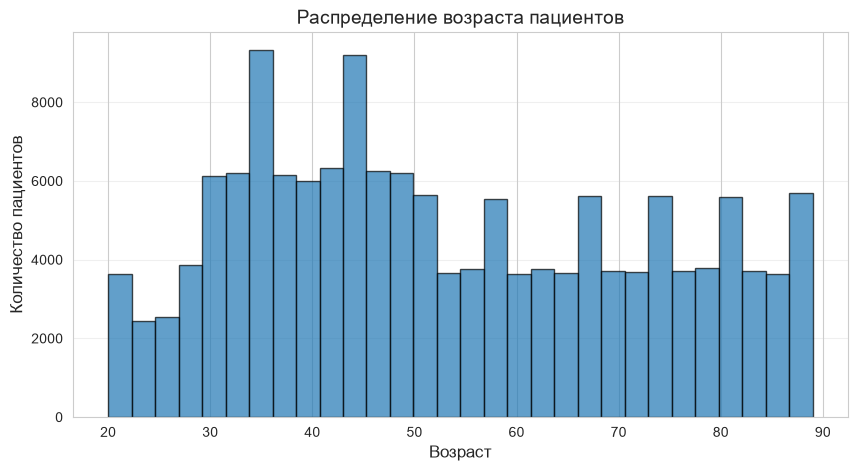

In [10]:
# 1. Гистограмма возраста
plt.figure(figsize=(10, 5))
df_train['age'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.title('Распределение возраста пациентов', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Количество пациентов', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

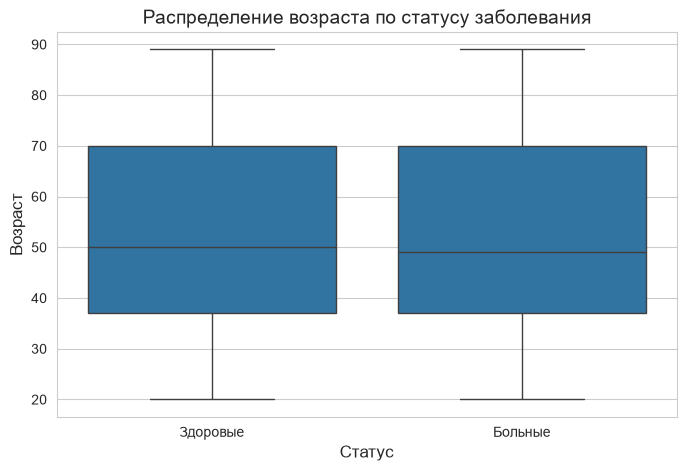

In [11]:
# 2. Ящик с усами (возраст по статусу)
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='age', data=df_train)
plt.title('Распределение возраста по статусу заболевания', fontsize=14)
plt.xticks([0, 1], ['Здоровые', 'Больные'])
plt.xlabel('Статус', fontsize=12)
plt.ylabel('Возраст', fontsize=12)
plt.show()

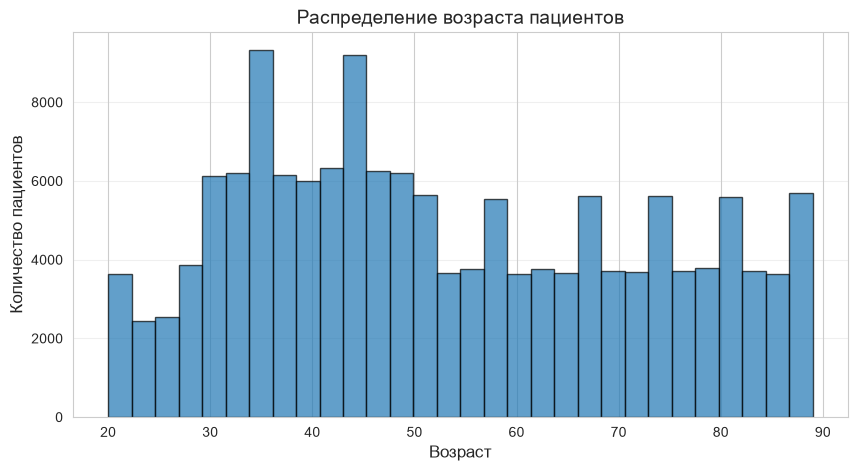

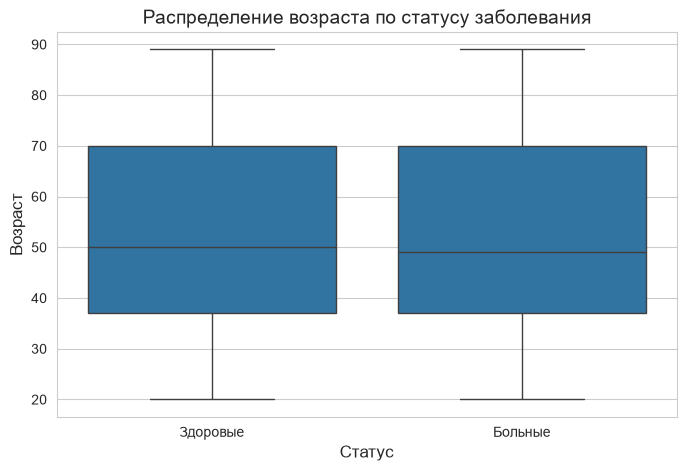

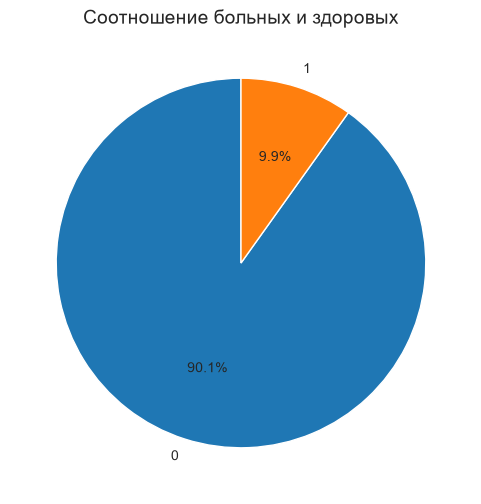

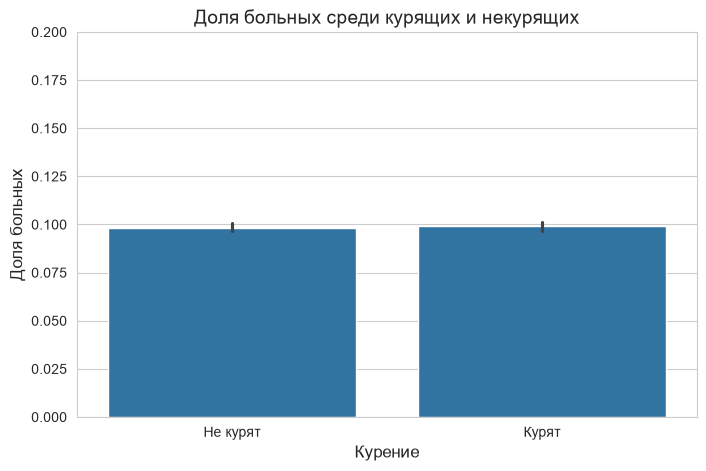

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Загружаем данные
df_train = pd.read_csv('../data/processed/train.csv')

# 1. Гистограмма возраста
plt.figure(figsize=(10, 5))
df_train['age'].hist(bins=30, edgecolor='black', alpha=0.7)
plt.title('Распределение возраста пациентов', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Количество пациентов', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Ящик с усами (возраст по статусу)
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='age', data=df_train)
plt.title('Распределение возраста по статусу заболевания', fontsize=14)
plt.xticks([0, 1], ['Здоровые', 'Больные'])
plt.xlabel('Статус', fontsize=12)
plt.ylabel('Возраст', fontsize=12)
plt.show()

# 3. Соотношение больных и здоровых (круговая диаграмма)
plt.figure(figsize=(6, 6))
df_train['label'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Соотношение больных и здоровых', fontsize=14)
plt.ylabel('')
plt.show()

# 4. Влияние курения (столбчатая диаграмма)
plt.figure(figsize=(8, 5))
sns.barplot(x='smoking_habits', y='label', data=df_train)
plt.title('Доля больных среди курящих и некурящих', fontsize=14)
plt.xticks([0, 1], ['Не курят', 'Курят'])
plt.xlabel('Курение', fontsize=12)
plt.ylabel('Доля больных', fontsize=12)
plt.ylim(0, 0.2)
plt.show()